# 03 — Feed-Forward Neural Network

**Owner:** Keana Gindlesperger (T1)  
**Reads:** `load_features("fit")`, `load_features("val")`  
**Writes:** `artifacts/nn_model.keras`, `outputs/predictions/03-nn_val.parquet`, `outputs/tables/03-nn_training_history.csv`

This notebook trains a feed-forward neural network on the same canonical TF-IDF feature space used by logistic regression. It tunes only against the validation split, freezes the best model, and writes validation predictions for the downstream evaluation notebook. The held-out test split is never loaded here.

In [1]:
# Shared foundation from src/shared.py
import pathlib
import sys
from IPython.display import display

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

from shared import (
    PATHS,
    PREDICTION_SCHEMA,
    SEED,
    TUNING_BUDGETS,
    compute_metrics,
    load_features,
)

import json
import os
import random
import time

import numpy as np
import pandas as pd

# Keep TF's own startup/deprecation chatter out of committed output cells:
# it logs the caller's *local* file path (e.g. an absolute .venv path with the
# machine's username), which is exactly what this public repo must never commit.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

try:
    import tensorflow as tf
    from tensorflow import keras
except ImportError as exc:
    raise RuntimeError(
        "TensorFlow is required for notebook 03. From the repository root, run "
        "`uv add tensorflow` and then `uv sync`."
    ) from exc

tf.get_logger().setLevel("ERROR")

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Ask TensorFlow for deterministic operations when the installed version supports it.
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

ARTIFACTS = PATHS["artifacts_dir"]
PRED = PATHS["predictions_dir"]
TBL = PATHS["tables_dir"]
for directory in (ARTIFACTS, PRED, TBL):
    directory.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACTS / "nn_model.keras"
PREDICTIONS_PATH = PRED / "03-nn_val.parquet"
HISTORY_PATH = TBL / "03-nn_training_history.csv"
TUNING_PATH = TBL / "03-nn_tuning_results.csv"
CONFIG_PATH = TBL / "03-nn_best_config.json"

print("TensorFlow:", tf.__version__)
print("SEED:", SEED)
print("Neural-network tuning budget:", TUNING_BUDGETS["nn_max_configs"])

TensorFlow: 2.21.0
SEED: 42
Neural-network tuning budget: 6


## Load the canonical fit and validation features

`shared.load_features()` transforms the saved split text with the TF-IDF vectorizer created by notebook 00. It does not refit the vectorizer, which prevents validation leakage. The sparse matrices remain sparse rather than being converted into one very large dense array.

In [2]:
X_fit, y_fit, fit_ids = load_features("fit")
X_val, y_val, val_ids = load_features("val")

assert X_fit.shape[0] == len(y_fit) == len(fit_ids)
assert X_val.shape[0] == len(y_val) == len(val_ids)
assert X_fit.shape[1] == X_val.shape[1]
assert set(np.unique(y_fit)).issubset({0, 1})
assert set(np.unique(y_val)).issubset({0, 1})

print("Fit shape:", X_fit.shape)
print("Validation shape:", X_val.shape)
print("Fit class balance:")
print(
    y_fit.value_counts(normalize=True)
    .sort_index()
    .rename({0: "negative", 1: "positive"})
)

Fit shape: (10000, 20000)
Validation shape: (5000, 20000)
Fit class balance:
label
negative    0.5
positive    0.5
Name: proportion, dtype: float64


## Model design

The input is the shared TF-IDF vector. The network uses:

- one or two fully connected hidden layers with ReLU activation;
- dropout to reduce overfitting;
- L2 weight regularization;
- one sigmoid output for binary sentiment;
- binary cross-entropy optimized with Adam.

The small configuration grid stays within the project's maximum of six neural-network configurations. Early stopping monitors validation loss and restores each run's best weights.


In [3]:
CONFIGS = [
    {
        "name": "nn_128",
        "hidden_units": [128],
        "dropout": 0.30,
        "l2": 1e-4,
        "learning_rate": 1e-3,
        "batch_size": 128,
    },
    {
        "name": "nn_256_64",
        "hidden_units": [256, 64],
        "dropout": 0.40,
        "l2": 1e-4,
        "learning_rate": 1e-3,
        "batch_size": 128,
    },
    {
        "name": "nn_128_32_stronger_reg",
        "hidden_units": [128, 32],
        "dropout": 0.50,
        "l2": 1e-3,
        "learning_rate": 5e-4,
        "batch_size": 128,
    },
]

assert len(CONFIGS) <= TUNING_BUDGETS["nn_max_configs"]


def build_model(input_dim, config):
    """Build and compile one sparse-input feed-forward classifier."""
    inputs = keras.Input(shape=(input_dim,), sparse=True, name="tfidf")
    x = inputs

    for layer_number, units in enumerate(config["hidden_units"], start=1):
        x = keras.layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(config["l2"]),
            name=f"dense_{layer_number}",
        )(x)
        x = keras.layers.Dropout(
            config["dropout"],
            seed=SEED + layer_number,
            name=f"dropout_{layer_number}",
        )(x)

    outputs = keras.layers.Dense(1, activation="sigmoid", name="sentiment")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name=config["name"])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="roc_auc"),
        ],
    )
    return model

## Tune on validation data

Selection uses **validation ROC-AUC**, with validation loss as the tie-breaker. Accuracy is still reported, but ROC-AUC evaluates ranking quality across thresholds and is useful for comparing probabilistic binary classifiers.


In [4]:
MAX_EPOCHS = 30
PATIENCE = 4

tuning_rows = []
run_histories = {}
best_model = None
best_config = None
best_score = (-np.inf, np.inf)  # maximize ROC-AUC, then minimize loss

for run_number, config in enumerate(CONFIGS, start=1):
    print(f"\n--- Run {run_number}/{len(CONFIGS)}: {config['name']} ---")
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = build_model(X_fit.shape[1], config)
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            min_delta=1e-4,
            restore_best_weights=True,
            verbose=1,
        )
    ]

    started = time.perf_counter()
    history = model.fit(
        X_fit,
        y_fit.to_numpy(dtype=np.float32),
        validation_data=(X_val, y_val.to_numpy(dtype=np.float32)),
        epochs=MAX_EPOCHS,
        batch_size=config["batch_size"],
        callbacks=callbacks,
        verbose=2,
        shuffle=True,
    )
    elapsed_seconds = time.perf_counter() - started

    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
    history_df.insert(0, "config_name", config["name"])
    run_histories[config["name"]] = history_df

    val_proba = model.predict(X_val, batch_size=512, verbose=0).ravel()
    val_pred = (val_proba >= 0.5).astype(int)
    metrics = compute_metrics(y_val, val_pred, y_proba_pos=val_proba)

    best_epoch_idx = int(history_df["val_loss"].idxmin())
    best_epoch = int(history_df.loc[best_epoch_idx, "epoch"])
    best_val_loss = float(history_df.loc[best_epoch_idx, "val_loss"])

    row = {
        "config_name": config["name"],
        "hidden_units": "-".join(map(str, config["hidden_units"])),
        "dropout": config["dropout"],
        "l2": config["l2"],
        "learning_rate": config["learning_rate"],
        "batch_size": config["batch_size"],
        "epochs_ran": len(history_df),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "elapsed_seconds": elapsed_seconds,
        **{k: v for k, v in metrics.items() if k != "confusion_matrix"},
    }
    tuning_rows.append(row)
    print(pd.Series(row))

    score = (metrics["roc_auc"], -best_val_loss)
    if score > (best_score[0], -best_score[1]):
        best_score = (metrics["roc_auc"], best_val_loss)
        best_model = model
        best_config = config.copy()

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(["roc_auc", "best_val_loss"], ascending=[False, True])
    .reset_index(drop=True)
)
tuning_results.to_csv(TUNING_PATH, index=False)

print("\nTuning results:")
display(tuning_results)
print("\nSelected configuration:", best_config["name"])


--- Run 1/3: nn_128 ---
Epoch 1/30
79/79 - 4s - 47ms/step - accuracy: 0.8198 - loss: 0.5757 - precision: 0.8075 - recall: 0.8398 - roc_auc: 0.8935 - val_accuracy: 0.8810 - val_loss: 0.4433 - val_precision: 0.8790 - val_recall: 0.8836 - val_roc_auc: 0.9487
Epoch 2/30
79/79 - 3s - 35ms/step - accuracy: 0.9081 - loss: 0.3611 - precision: 0.9035 - recall: 0.9138 - roc_auc: 0.9715 - val_accuracy: 0.8950 - val_loss: 0.3721 - val_precision: 0.8914 - val_recall: 0.8996 - val_roc_auc: 0.9594
Epoch 3/30
79/79 - 3s - 40ms/step - accuracy: 0.9454 - loss: 0.2892 - precision: 0.9417 - recall: 0.9496 - roc_auc: 0.9876 - val_accuracy: 0.8966 - val_loss: 0.3581 - val_precision: 0.8924 - val_recall: 0.9020 - val_roc_auc: 0.9611
Epoch 4/30
79/79 - 3s - 38ms/step - accuracy: 0.9661 - loss: 0.2518 - precision: 0.9625 - recall: 0.9700 - roc_auc: 0.9940 - val_accuracy: 0.8958 - val_loss: 0.3552 - val_precision: 0.8988 - val_recall: 0.8920 - val_roc_auc: 0.9607
Epoch 5/30
79/79 - 3s - 37ms/step - accuracy: 0

,config_name,hidden_units,dropout,l2,learning_rate,batch_size,epochs_ran,best_epoch,best_val_loss,elapsed_seconds,accuracy,precision,recall,f1,roc_auc
0,nn_256_64,256-64,0.4,0.0001,0.0010,128,5,1,0.324752,38.431704,0.8956,0.886027,0.9080,0.896879,0.959873
1,nn_128_32_stronger_reg,128-32,0.5,0.0010,0.0005,128,8,4,0.438607,26.378467,0.8946,0.887318,0.9040,0.895582,0.959770
2,nn_128,128,0.3,0.0001,0.0010,128,10,6,0.354033,30.060660,0.8926,0.893387,0.8916,0.892492,0.958934



Selected configuration: nn_256_64


## Freeze the selected model and write handoff artifacts

The selected model is saved in Keras format. Validation probabilities are converted to labels at the standard 0.50 threshold and written using the shared prediction schema. The history file contains only the selected model's epoch-by-epoch training record; the separate tuning table preserves the comparison across configurations.


In [6]:
assert best_model is not None and best_config is not None

# Save the frozen model.
best_model.save(MODEL_PATH)

# Save the chosen configuration in a human-readable form.
with open(CONFIG_PATH, "w", encoding="utf-8") as file:
    json.dump(best_config, file, indent=2)

# Save selected model training history.
selected_history = run_histories[best_config["name"]].copy()
selected_history.to_csv(HISTORY_PATH, index=False)

# Create the validation prediction handoff.
y_proba_pos = best_model.predict(X_val, batch_size=512, verbose=0).ravel()
y_pred = (y_proba_pos >= 0.5).astype(int)

val_predictions = pd.DataFrame(
    {
        "id": val_ids.astype(str),
        "y_true": y_val.astype(int),
        "y_pred": y_pred.astype(int),
        "y_proba_pos": y_proba_pos.astype(float),
    }
)[PREDICTION_SCHEMA]

assert val_predictions["id"].is_unique
assert val_predictions["y_true"].isin([0, 1]).all()
assert val_predictions["y_pred"].isin([0, 1]).all()
assert val_predictions["y_proba_pos"].between(0.0, 1.0).all()
assert len(val_predictions) == len(y_val)

val_predictions.to_parquet(PREDICTIONS_PATH, index=False)

final_metrics = compute_metrics(
    val_predictions["y_true"],
    val_predictions["y_pred"],
    y_proba_pos=val_predictions["y_proba_pos"].to_numpy(),
)

print("Saved model:", MODEL_PATH.relative_to(PATHS["repo_root"]))
print("Saved predictions:", PREDICTIONS_PATH.relative_to(PATHS["repo_root"]))
print("Saved selected history:", HISTORY_PATH.relative_to(PATHS["repo_root"]))
print("Saved tuning results:", TUNING_PATH.relative_to(PATHS["repo_root"]))
print("Saved best configuration:", CONFIG_PATH.relative_to(PATHS["repo_root"]))
print("\nValidation metrics:")
print(pd.Series(final_metrics))

Saved model: artifacts\nn_model.keras
Saved predictions: outputs\predictions\03-nn_val.parquet
Saved selected history: outputs\tables\03-nn_training_history.csv
Saved tuning results: outputs\tables\03-nn_tuning_results.csv
Saved best configuration: outputs\tables\03-nn_best_config.json

Validation metrics:
accuracy                                0.8956
precision                             0.886027
recall                                   0.908
f1                                    0.896879
roc_auc                               0.959873
confusion_matrix    [[2208, 292], [230, 2270]]
dtype: object


## Training curves for the selected model

Loss and accuracy by epoch for the frozen configuration, with a marker at the epoch whose weights early stopping restored.

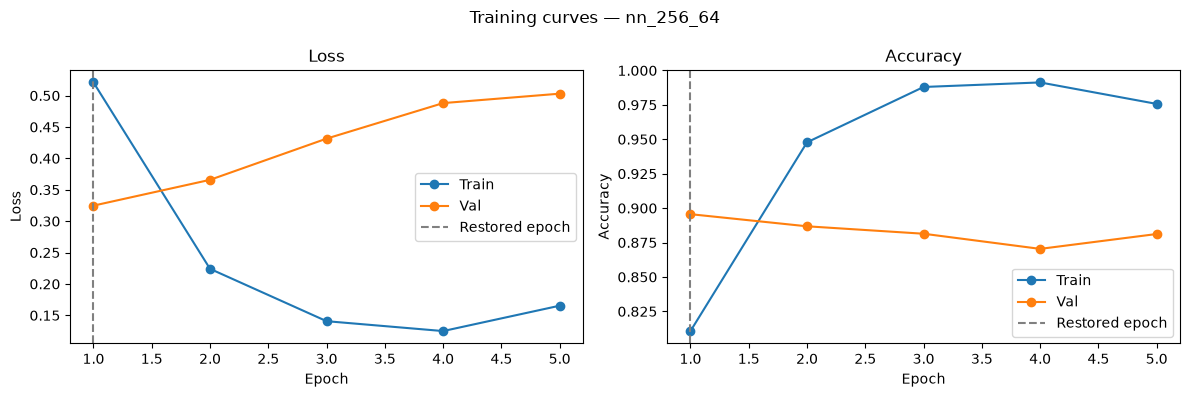

Saved figure: outputs\figures\03-nn_training_curves.png


In [7]:
best_epoch_for_selected = int(
    tuning_results.loc[
        tuning_results["config_name"] == best_config["name"], "best_epoch"
    ].iloc[0]
)

TRAINING_CURVES_PATH = FIG / "03-nn_training_curves.png"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(selected_history["epoch"], selected_history["loss"], marker="o", label="Train")
axes[0].plot(selected_history["epoch"], selected_history["val_loss"], marker="o", label="Val")
axes[0].axvline(best_epoch_for_selected, color="gray", linestyle="--", label="Restored epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(selected_history["epoch"], selected_history["accuracy"], marker="o", label="Train")
axes[1].plot(selected_history["epoch"], selected_history["val_accuracy"], marker="o", label="Val")
axes[1].axvline(best_epoch_for_selected, color="gray", linestyle="--", label="Restored epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

fig.suptitle(f"Training curves \u2014 {best_config['name']}")
plt.tight_layout()
plt.savefig(TRAINING_CURVES_PATH, dpi=150)
plt.show()

print("Saved figure:", TRAINING_CURVES_PATH.relative_to(PATHS["repo_root"]))

## Handoff checks

These checks confirm that notebook 04 can reload the saved model and that all required files exist. Notebook 03 stops here without loading or scoring the test split.

In [8]:
required_outputs = [
    MODEL_PATH,
    PREDICTIONS_PATH,
    HISTORY_PATH,
    TUNING_PATH,
    CONFIG_PATH,
]
missing = [str(path) for path in required_outputs if not path.exists()]
assert not missing, f"Missing outputs: {missing}"

reloaded_model = keras.models.load_model(MODEL_PATH)
sample_probability = float(reloaded_model.predict(X_val[:1], verbose=0).ravel()[0])
assert 0.0 <= sample_probability <= 1.0

print("All handoff artifacts exist.")
print("Reloaded model sample probability:", sample_probability)
print("Notebook 03 complete. The test split was not loaded.")

All handoff artifacts exist.
Reloaded model sample probability: 0.47695741057395935
Notebook 03 complete. The test split was not loaded.
